<a href="https://colab.research.google.com/github/Dheatrilova/Responsi-AI/blob/main/animal_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Skipping, found downloaded files in "./animal-faces" (use force=True to force download)


In [3]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [28]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns = ["image_path", "labels"])
print(data_df["labels"].unique())
data_df.head()

['cat' 'dog' 'wild']


,image_path,labels
0,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
1,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
2,/content/animal-faces/afhq/val/cat/flickr_cat_...,cat
3,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat
4,/content/animal-faces/afhq/val/cat/pixabay_cat...,cat


In [29]:
train = data_df.sample(frac=0.7, random_state=42)
temp = data_df.drop(train.index)

val = temp.sample(frac=0.5, random_state=42)
test = temp.drop(val.index)

In [30]:
transform = transforms.Compose([
    transforms.Resize((128,128)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [31]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform = None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe['labels'])).to(device)

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label

In [32]:
train_dataset = CustomImageDataset(dataframe = train, transform = transform)
test_dataset = CustomImageDataset(dataframe = test, transform = transform)
val_dataset = CustomImageDataset(dataframe = val, transform = transform)

In [33]:
print(train.iloc[2, 0])

/content/animal-faces/afhq/train/wild/flickr_wild_000674.jpg


In [35]:
train_dataset.__getitem__(2)

(tensor([[[ 0.0902,  0.1216,  0.1686,  ..., -0.0510, -0.0431, -0.0353],
          [ 0.1451,  0.1686,  0.1843,  ..., -0.0196, -0.0118, -0.0196],
          [ 0.1843,  0.2235,  0.2235,  ..., -0.0353, -0.0118, -0.0118],
          ...,
          [-0.3569, -0.3255, -0.3490,  ...,  0.0353,  0.0588,  0.0431],
          [-0.2157, -0.1843, -0.2157,  ..., -0.1922,  0.1137,  0.3333],
          [-0.1608, -0.2000, -0.1294,  ..., -0.1922,  0.0667,  0.4118]],
 
         [[ 0.1686,  0.1765,  0.2078,  ...,  0.0745,  0.1059,  0.1216],
          [ 0.2078,  0.2157,  0.2078,  ...,  0.1137,  0.1373,  0.1451],
          [ 0.2235,  0.2471,  0.2392,  ...,  0.1137,  0.1529,  0.1686],
          ...,
          [-0.3333, -0.3098, -0.3255,  ...,  0.0980,  0.1373,  0.1294],
          [-0.2078, -0.1686, -0.2000,  ..., -0.0902,  0.2235,  0.4510],
          [-0.1529, -0.1843, -0.1137,  ..., -0.0510,  0.1765,  0.5059]],
 
         [[ 0.0824,  0.1216,  0.1765,  ...,  0.1765,  0.1922,  0.2078],
          [ 0.1294,  0.1529,

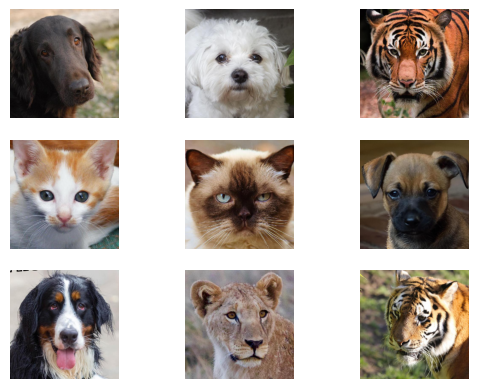

In [36]:
n_rows = 3
n_cols = 3

f, axarr = plt.subplots(n_rows, n_cols)

for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(data_df.sample(n=1)["image_path"].iloc[0]).convert("RGB")
    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')

In [37]:
LR = 0.0001
BATCH_SIZE = 32
EPOCHS = 5

In [38]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [39]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()
    self.dropout = nn.Dropout(0.5)

    self.linear = nn.Linear(128*16*16, 128)
    self.output = nn.Linear(128, len(data_df['labels'].unique()))

  def forward(self, x):
    x = self.pooling(self.relu(self.conv1(x)))
    x = self.pooling(self.relu(self.conv2(x)))
    x = self.pooling(self.relu(self.conv3(x)))

    x = self.flatten(x)
    x = self.dropout(x)
    x = self.linear(x)
    x = self.output(x)

    return x

In [40]:
model = Net().to(device)

In [41]:
from torchsummary import summary
summary(model, input_size = (3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
              ReLU-2         [-1, 32, 128, 128]               0
         MaxPool2d-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
              ReLU-5           [-1, 64, 64, 64]               0
         MaxPool2d-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
              ReLU-8          [-1, 128, 32, 32]               0
         MaxPool2d-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
          Dropout-11                [-1, 32768]               0
           Linear-12                  [-1, 128]       4,194,432
           Linear-13                    [-1, 3]             387
Total params: 4,288,067
Trainable param

In [42]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [43]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_loss_val = 0
  total_acc_val = 0

  for inputs, labels in train_loader:
    optimizer.zero_grad()
    outputs = model(inputs)
    train_loss = criterion(outputs, labels)
    total_loss_train += train_loss.item()

    train_loss.backward()

    train_acc = (torch.argmax(outputs, axis = 1) == labels).sum().item()

    total_acc_train += train_acc
    optimizer.step()

  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = model(inputs)
      val_loss = criterion(outputs, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(outputs, axis= 1) == labels).sum().item()
      total_acc_val += val_acc

  total_loss_train_plot.append(round(total_loss_train/1000, 4))
  total_loss_validation_plot.append(round(total_loss_val/1000, 4))

  total_acc_train_plot.append(round((total_acc_train/train_dataset.__len__()) * 100, 4))
  total_acc_validation_plot.append(round((total_acc_val/val_dataset.__len__()) * 100, 4))

  print(f'''Epoch {epoch +1}/{EPOCHS},
            Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round((total_acc_train/train_dataset.__len__()) * 100, 4)}
            Validation Loss {round(total_loss_val/1000, 4)} Validation Accuracy {round((total_acc_val/val_dataset.__len__()) * 100, 4)}
        ''')

Epoch 1/5,
            Train Loss: 0.1651 Train Accuracy 81.1886
            Validation Loss 0.0226 Validation Accuracy 89.1736
        
Epoch 2/5,
            Train Loss: 0.0828 Train Accuracy 91.2408
            Validation Loss 0.0156 Validation Accuracy 92.438
        
Epoch 3/5,
            Train Loss: 0.0563 Train Accuracy 94.3229
            Validation Loss 0.0133 Validation Accuracy 93.4298
        
Epoch 4/5,
            Train Loss: 0.044 Train Accuracy 95.554
            Validation Loss 0.0107 Validation Accuracy 94.4215
        
Epoch 5/5,
            Train Loss: 0.0358 Train Accuracy 96.5459
            Validation Loss 0.0107 Validation Accuracy 94.876
        


In [44]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  for inputs, labels in test_loader:
    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis = 1) == labels).sum().item()
    total_acc_test += acc
    test_loss = criterion(predictions, labels)
    total_loss_test += test_loss.item()

print(f"Accuracy Score is: {round((total_acc_test/test_dataset.__len__()) * 100, 4)} and Loss is {round(total_loss_test/1000, 4)}")

Accuracy Score is: 95.2873 and Loss is 0.0098


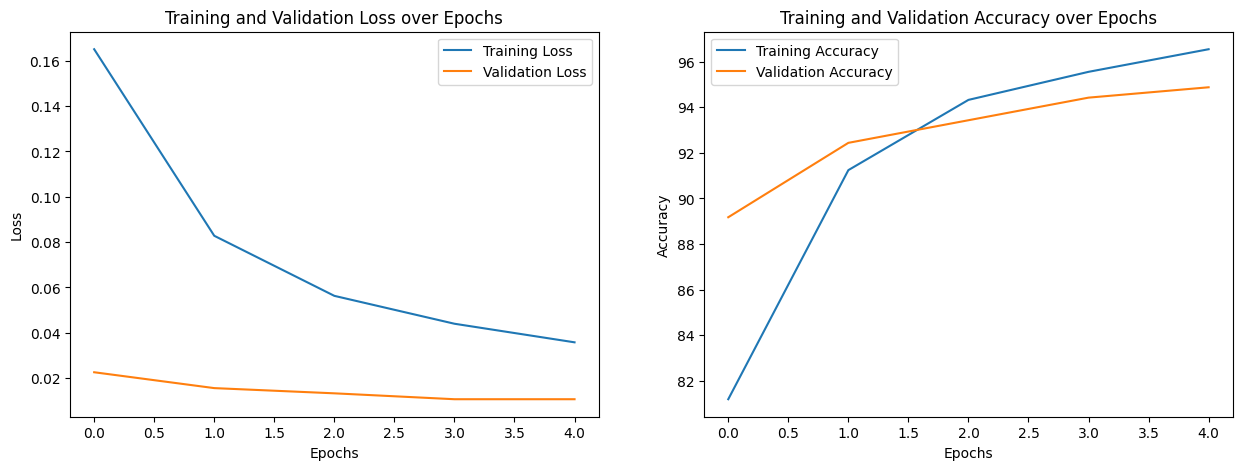

In [45]:
fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [49]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis= 1).item()
  return label_encoder.inverse_transform([output])

In [51]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

In [53]:
import os
print(os.path.exists("/content/cat.jpg"))

False
